**Created by Tahim Bhuiya**


**08/08/2026**

a) Using the mnist function in keras.datasets to load and split the MNIST dataset into the training and testing sets. Name the sets as x_train, y_train, and x_test, y_test. Print the following: The number of images in each training and testing set and the image width and height.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from keras.datasets import mnist

# load MNIST dataset
(x_train, y_train),(x_test, y_test)= mnist.load_data()

# print number of images and dimensions
print("Number of training images:", x_train.shape[0])
print("Number of testing images:", x_test.shape[0])
print("Image width:", x_train.shape[1])
print("Image height:", x_train.shape[2])

Number of training images: 60000
Number of testing images: 10000
Image width: 28
Image height: 28


b) Writing a function that takes two inputs: 1) images of ten digits and 2) their corresponding labels and plots a figure with 10 subplots for each 0-9 digits. Each subplot has the number of the handwritten digit in its title.

In [2]:
def img_plt(images,labels):
  plt.figure()
  for i in range(1,11):
    plt.subplot(2,5,i)
    plt.imshow(images[i-1,:,:],cmap='gray')
    plt.title('Label: ' + str(labels[i-1]))
  plt.show()


c) Creating a loop to call the function in (b) and plot images from the training set to create a figure that includes all the 10 digits (0-9).

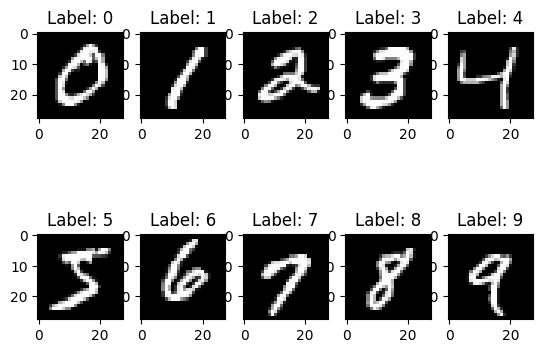

In [3]:
x_train_rnd=np.zeros((10,28,28))
y_train_rnd=np.arange(10)
for digit in range(10):
  x_train_d=x_train[y_train==digit,:,:]
  x_train_rnd[digit,:,:]=x_train_d[0,:,:]

img_plt(x_train_rnd,y_train_rnd)


d) Selecting the 1 and 5 digits from the training and testing sets and naming them:

x_train_01, y_train_01 and x_test_01, y_test_01.

In [4]:
# training set
x_train_01 = x_train[np.logical_or(y_train == 1, y_train == 5)]
y_train_01 = y_train[np.logical_or(y_train == 1, y_train == 5)]

# testing set
x_test_01 = x_test[np.logical_or(y_test == 1, y_test == 5)]
y_test_01 = y_test[np.logical_or(y_test == 1, y_test == 5)]

e) In machine learning, we typically divide the training set into two training and validation sets to adjust the machine learning model parameters. In your code, randomly select 100 training images and their corresponding labels (from x_train_01 and y_train_01) as the validation set and name them x_valid_01 and y_valid_01, respectively. Name the remaining training images and their labels as x_train_01 and y_train_01, respectively. Note: There are no overlaps between the two sets.

In [5]:
# create indices for the training set of 1's and 5's
indices = np.arange(x_train_01.shape[0])

# randomly permute the indices
shuffled_indices = np.random.permutation(indices)

# select first 100 for validation
val_indices = shuffled_indices[:100]
train_indices = shuffled_indices[100:]

# assign validation and training images
x_valid_01 = x_train_01[val_indices]
y_valid_01 = y_train_01[val_indices]

x_train_01 = x_train_01[train_indices]
y_train_01 = y_train_01[train_indices]


f) Printing the number of images in each training, validation, and testing set.

In [6]:
print("Number of training images (1 & 5):", x_train_01.shape[0])
print("Number of validation images (1 & 5):", x_valid_01.shape[0])
print("Number of testing images (1 & 5):", x_test_01.shape[0])

Number of training images (1 & 5): 12063
Number of validation images (1 & 5): 100
Number of testing images (1 & 5): 2027


g) Using the function created in part (b) to plot 10 images from the validation set.

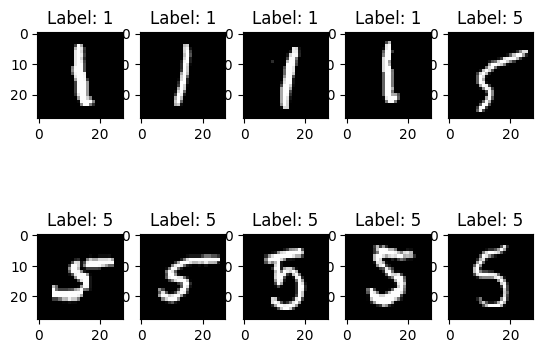

In [7]:
img_plt(x_valid_01, y_valid_01)


h) Convert each image in the three training, validation, and testing sets to one attribute by calculating the average of all the pixel values in the center 4x4 grid of the image.

In [8]:
# number of pixels in the 4x4 center grid
num_pixels = 4 * 4

# training set
x_train_01_center = np.sum(x_train_01[:, 12:16, 12:16], axis=(1, 2)) / num_pixels

# validation set
x_valid_01_center = np.sum(x_valid_01[:, 12:16, 12:16], axis=(1, 2)) / num_pixels

# testing set
x_test_01_center  = np.sum(x_test_01[:, 12:16, 12:16], axis=(1, 2)) / num_pixels

# printing first few attribute values to check
print("First 10 training attributes:", x_train_01_center[:10])
print("First 10 validation attributes:", x_valid_01_center[:10])
print("First 10 test attributes:", x_test_01_center[:10])




First 10 training attributes: [172.4375 132.375   93.875  166.125  156.125  132.     171.5625 169.9375
 147.     116.6875]
First 10 validation attributes: [233.25   138.125  162.3125 189.      48.4375 196.5     97.625  123.125
  88.25   111.125 ]
First 10 test attributes: [121.4375 164.3125  18.125  191.25    40.625   83.5    172.1875 131.125
 182.6875 244.75  ]


i) Plot the attribute values of the 100 images in the validation set that you calculated in part (h). Use different colors and shapes for 1's and 5's. The x-axis in your figure is the image number (1 to 100), and the y-axis is the calculated attribute. Label the axes and add legends appropriately.

In [ ]:
def feat_plt(feature, labels, digit_a, digit_b):
    plt.figure(figsize=(10, 5))
    sample_nums = np.arange(feature.shape[0])
    plt.plot(sample_nums[labels == digit_a], feature[labels == digit_a],
             'gs', label='Digit ' + str(digit_a))
    plt.plot(sample_nums[labels == digit_b], feature[labels == digit_b],
             'r^', label='Digit ' + str(digit_b))

    plt.xlabel('Image number (1 to 100)')
    plt.ylabel('Average of 4x4 center grid')






